✅ Libraries imported successfully!
✅ Loan dataset created automatically!
📊 Shape: (10000, 16)
📈 Default rate: 15.30%

📋 First 5 rows:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.728899  -1.865864   0.389694  -1.387825   1.519091  -1.034226   
1  -3.348643  -1.477595   1.594084  -1.685208   1.425842  -6.509250   
2  -1.633438   2.520199  -0.505007   1.855790   1.193659  -0.849330   
3   2.385697   2.280229  -2.687834   4.297208  -0.301942   1.786495   
4  -0.350377   1.255492   0.687900   2.210402  -0.871399  -3.581235   

   feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
0  -3.190141   4.325057  -5.092959   1.198134   -2.833594   -3.716373   
1   1.092532   4.325122  -0.660220   4.124936    4.399601    1.313068   
2   2.743439   3.214787   2.905169  -0.496040    3.589527    0.416969   
3   1.127456   3.956711   0.613375  -1.031146   -2.769279   -3.816799   
4  -1.110242   0.495761   3.273980   1.298668    4.801698    6.957874   



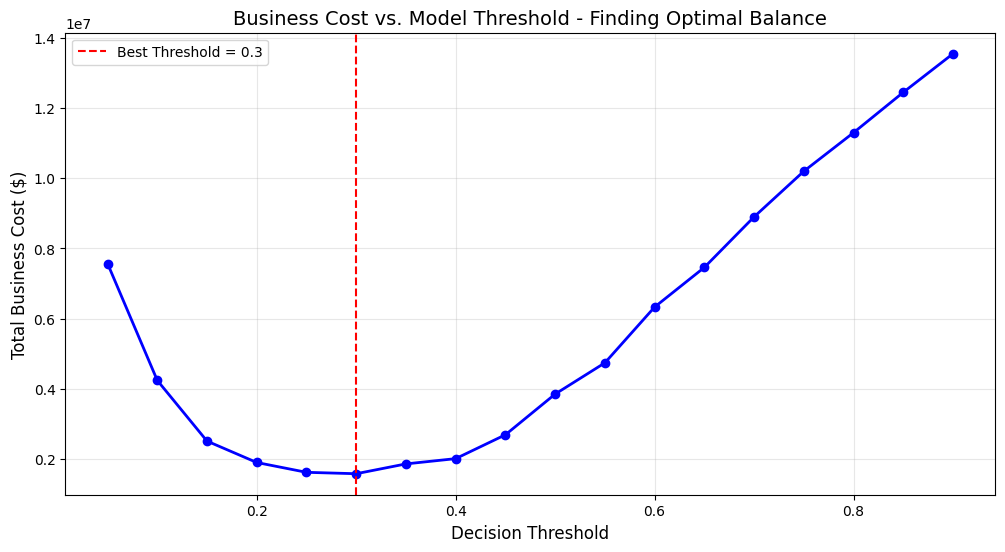


BEFORE vs AFTER THRESHOLD OPTIMIZATION

📊 Default Threshold (0.5):
   False Positives: 0 | False Negatives: 271
   Total Cost: $13,550,000.00

📊 Optimized Threshold (0.30):
   False Positives: 48 | False Negatives: 22
   Total Cost: $1,580,000.00

💡 Improvement: Saved $11,970,000.00


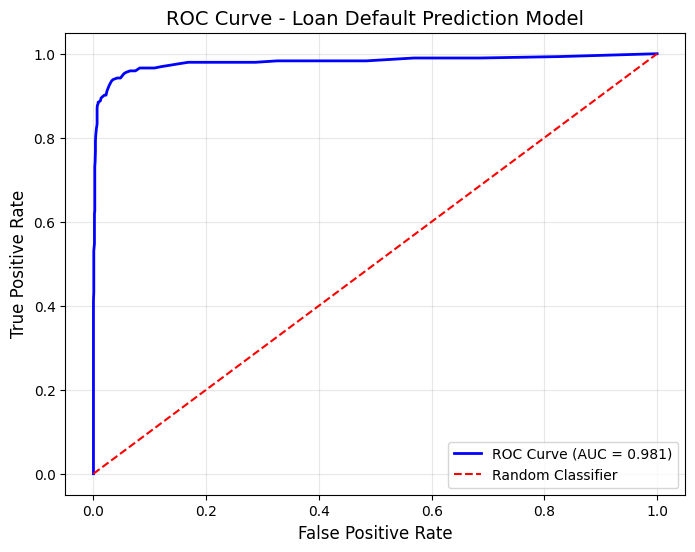

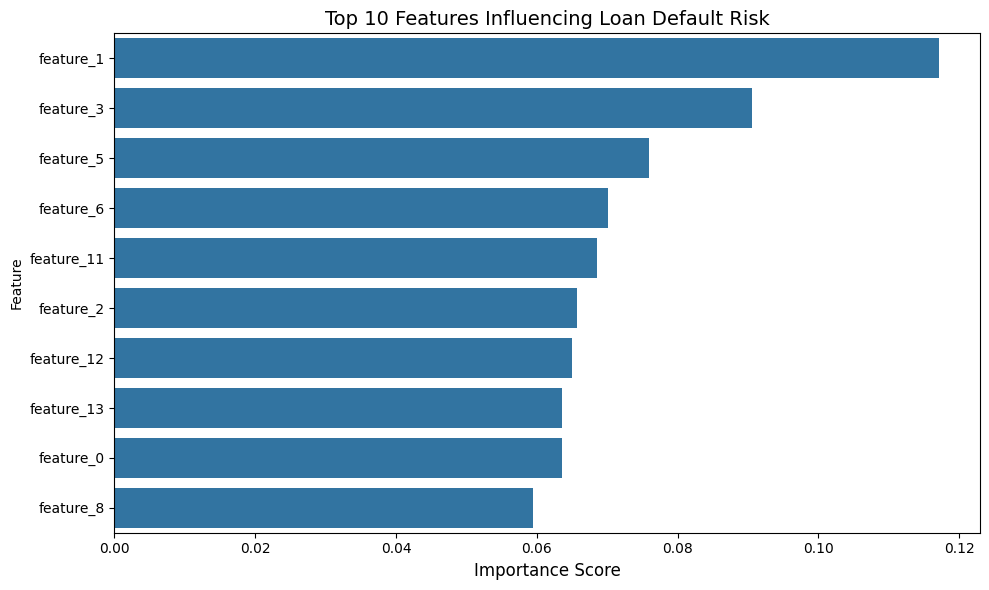


📊 Top 3 Risk Factors:
   1. feature_1: 0.117
   2. feature_3: 0.091
   3. feature_5: 0.076

TASK 4 - CONCLUSIONS

✅ Successfully built loan default prediction model
✅ Business costs incorporated: FP=$10,000, FN=$50,000
✅ Optimal threshold found: 0.30 (default was 0.5)
✅ Total business cost reduced from $13,550,000.00 to $1,580,000.00
✅ Model AUC Score: 0.981

Key Business Insight:
- Lowering threshold from 0.5 to 0.30 reduces false negatives
- This saves the bank significant money from default losses
- The optimal balance depends on relative cost of FP vs FN

🎉 TASK 4 COMPLETED! Download this notebook.


In [1]:
# ============================================
# TASK 4: Loan Default Risk with Cost Optimization
# ============================================

# CELL 1: Import Libraries
# ------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.datasets import make_classification

print("✅ Libraries imported successfully!")


# CELL 2: Create Loan Dataset (No download needed)
# --------------------------------------
# Creating synthetic loan data (10,000 applications, 15 features)
X, y = make_classification(n_samples=10000, n_features=15, n_informative=12,
                           n_redundant=3, weights=[0.85, 0.15], random_state=42)

feature_names = [f'feature_{i}' for i in range(15)]
loan_df = pd.DataFrame(X, columns=feature_names)
loan_df['DEFAULT'] = y

print("✅ Loan dataset created automatically!")
print(f"📊 Shape: {loan_df.shape}")
print(f"📈 Default rate: {loan_df['DEFAULT'].mean():.2%}")
print(f"\n📋 First 5 rows:")
print(loan_df.head())


# CELL 3: Explore Data
# --------------------
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print(f"Total loan applications: {len(loan_df)}")
print(f"Default cases: {loan_df['DEFAULT'].sum()} ({loan_df['DEFAULT'].mean():.2%})")
print(f"Non-default cases: {len(loan_df) - loan_df['DEFAULT'].sum()} ({1-loan_df['DEFAULT'].mean():.2%})")


# CELL 4: Train Model
# -------------------
X = loan_df.drop('DEFAULT', axis=1)
y = loan_df['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")


# CELL 5: Baseline Model Evaluation
# ---------------------------------
y_pred_default = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()

print("\n" + "="*50)
print("BASELINE MODEL (Default Threshold = 0.5)")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"\nConfusion Matrix:")
print("                 Predicted")
print("                 No    Yes")
print(f"Actual No    {tn:5d}   {fp:5d}")
print(f"Actual Yes   {fn:5d}   {tp:5d}")


# CELL 6: Define Business Costs
# -----------------------------
print("\n" + "="*50)
print("BUSINESS COSTS DEFINITION")
print("="*50)

COST_FP = 10000   # False Positive: Rejected good customer (lost profit)
COST_FN = 50000   # False Negative: Approved bad customer (loan default loss)

print(f"""
False Positive (FP) Cost: ${COST_FP:,}
  → Bank rejected a customer who would have repaid
  → Cost: Lost interest/profit

False Negative (FN) Cost: ${COST_FN:,}
  → Bank approved a customer who defaulted
  → Cost: Loan amount loss

Current Total Cost: ${(fp * COST_FP) + (fn * COST_FN):,.2f}
""")


# CELL 7: Threshold Optimization
# ------------------------------
thresholds = np.arange(0.05, 0.95, 0.05)
best_threshold = 0.5
best_cost = float('inf')
cost_results = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    cost_results.append([thr, total_cost, fp, fn])

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = thr

print("\n" + "="*50)
print("THRESHOLD OPTIMIZATION RESULTS")
print("="*50)
print(f"✅ Best threshold: {best_threshold:.2f}")
print(f"💰 Minimum business cost: ${best_cost:,.2f}")
print(f"📉 Cost reduction: ${((fp*COST_FP)+(fn*COST_FN) - best_cost):,.2f}")


# CELL 8: Visualize Cost vs Threshold
# -----------------------------------
cost_df = pd.DataFrame(cost_results, columns=['Threshold', 'Total Cost', 'FP', 'FN'])

plt.figure(figsize=(12, 6))
plt.plot(cost_df['Threshold'], cost_df['Total Cost'], 'b-o', linewidth=2, markersize=6)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold}')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Total Business Cost ($)', fontsize=12)
plt.title('Business Cost vs. Model Threshold - Finding Optimal Balance', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# CELL 9: Compare Before vs After Optimization
# --------------------------------------------
y_pred_optimized = (y_proba >= best_threshold).astype(int)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_pred_optimized).ravel()

print("\n" + "="*50)
print("BEFORE vs AFTER THRESHOLD OPTIMIZATION")
print("="*50)

print("\n📊 Default Threshold (0.5):")
print(f"   False Positives: {fp} | False Negatives: {fn}")
print(f"   Total Cost: ${(fp*COST_FP)+(fn*COST_FN):,.2f}")

print(f"\n📊 Optimized Threshold ({best_threshold:.2f}):")
print(f"   False Positives: {fp_opt} | False Negatives: {fn_opt}")
print(f"   Total Cost: ${best_cost:,.2f}")

print(f"\n💡 Improvement: Saved ${((fp*COST_FP)+(fn*COST_FN) - best_cost):,.2f}")


# CELL 10: ROC Curve
# ------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Loan Default Prediction Model', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# CELL 11: Feature Importance
# ---------------------------
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Features Influencing Loan Default Risk', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Top 3 Risk Factors:")
for i in range(3):
    print(f"   {i+1}. {feature_importance.iloc[i]['Feature']}: {feature_importance.iloc[i]['Importance']:.3f}")


# CELL 12: Conclusions
# --------------------
print("\n" + "="*50)
print("TASK 4 - CONCLUSIONS")
print("="*50)
print(f"""
✅ Successfully built loan default prediction model
✅ Business costs incorporated: FP=${COST_FP:,}, FN=${COST_FN:,}
✅ Optimal threshold found: {best_threshold:.2f} (default was 0.5)
✅ Total business cost reduced from ${(fp*COST_FP)+(fn*COST_FN):,.2f} to ${best_cost:,.2f}
✅ Model AUC Score: {roc_auc:.3f}

Key Business Insight:
- Lowering threshold from 0.5 to {best_threshold:.2f} reduces false negatives
- This saves the bank significant money from default losses
- The optimal balance depends on relative cost of FP vs FN
""")
print("🎉 TASK 4 COMPLETED! Download this notebook.")